In [1]:
# ---------------------------------------------------------------------------
# Path setup — run this first. Anchors all paths to the repo root so the
# notebook works regardless of the directory it's launched from.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk upward until we find a dir containing both 'src' and 'data'."""
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    # Fallback: assume the notebook lives in <root>/notebooks/
    return start.parent


# Path.cwd() is where Jupyter was launched; __file__ isn't defined in nbs.
REPO_ROOT = _find_repo_root(Path.cwd())

DATA_DIR    = REPO_ROOT / "data" / "Scenario5"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (
    REPO_ROOT,                             
    REPO_ROOT / "src",
    _diffputer / "baselines" / "GRAPE",
    _diffputer / "baselines",
    _diffputer,
):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

In [2]:
# Check environment and imports
from common.environment import check_environment
check_environment()
# Enable automatic reloading of edited modules in this notebook
%load_ext autoreload
%autoreload 2

Required packages
------------------------------------------------------------
  ✓ numpy              OK       1.26.4
  ✓ pandas             OK       2.3.3
  ✓ scipy              OK       1.17.1
  ✓ scikit-learn       OK       1.6.1
  ✓ matplotlib         OK       3.10.9
  ✓ statsmodels        OK       0.14.6
  ✓ fancyimpute        OK       0.7.0
  ✓ hyperimpute        OK       0.1.17
  ✓ torch              OK       2.4.1
  ✓ torch_geometric    OK       2.7.0
  ✓ h5py               OK       3.14.0
  ✓ networkx           OK       3.6.1


I0000 00:00:1779717148.862507   21115 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


  ✓ POT                OK       0.9.6.post1
  ✓ FrEIA              OK       0.2
  ✓ timm               OK       1.0.27
  ✓ PyYAML             OK       6.0.3
  ✓ ipykernel          OK       7.2.0

Optional packages
------------------------------------------------------------
  ✓ torch_scatter      OK       2.1.2+pt24cu121

Smoke-test imports for imputation APIs
------------------------------------------------------------
  ✓ Mean / kNN (sklearn): OK
  ✓ MICE (sklearn IterativeImputer): OK
  ✓ SoftImpute / KNN / SimpleFill (fancyimpute): OK
  ✓ HyperImpute (hyperimpute.plugins.imputers.Imputers): OK
  ✓ PyTorch Geometric (for GRAPE): OK

Local repo modules (DiffPuter / GRAPE)
------------------------------------------------------------
  ✓ DiffPuter dataset: OK (dataset)
  ✓ DiffPuter diffusion: OK (diffusion_utils)
  ✓ DiffPuter model: OK (model)
  ✓ GRAPE training: OK (training.gnn_mdi)

All required packages present.


# Dataset Analysis
Perform simple data exploration: Shape, Columns, Data types, Missing values, First few rows

In [5]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Load the dataset
df = pd.read_csv(DATA_DIR / 'scenario5.csv')

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert relative paths to absolute for reference
base_dir = DATA_DIR

# Data exploration
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst few rows:")
df.head()

Shape: (2300, 15)

Columns: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit1_beam_index', 'seq_index', 'time_stamp[UTC]', 'unit2_direction', 'unit2_num_sat', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS', 'unit2_PDOP', 'unit2_HDOP']

Data types:
index                 int64
unit1_rgb            object
unit1_pwr_60ghz      object
unit1_loc            object
unit2_loc            object
unit1_beam_index      int64
seq_index             int64
time_stamp[UTC]      object
unit2_direction       int64
unit2_num_sat         int64
unit2_sat_used       object
unit2_fix_type       object
unit2_DGPS           object
unit2_PDOP          float64
unit2_HDOP          float64
dtype: object

Missing values:
index               0
unit1_rgb           0
unit1_pwr_60ghz     0
unit1_loc           0
unit2_loc           0
unit1_beam_index    0
seq_index           0
time_stamp[UTC]     0
unit2_direction     0
unit2_num_sat       0
unit2_sat_used      0
unit2_fix_type      0
unit2_DGPS

,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit1_beam_index,seq_index,time_stamp[UTC],unit2_direction,unit2_num_sat,unit2_sat_used,unit2_fix_type,unit2_DGPS,unit2_PDOP,unit2_HDOP
0,1,./unit1/camera_data/image_BS1_259_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_0.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_0.txt,60,1,['03-20-31-142'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
1,2,./unit1/camera_data/image_BS1_260_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,60,1,['03-20-31-284'],1,24,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
2,3,./unit1/camera_data/image_BS1_261_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,58,1,['03-20-31-426'],1,14,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
3,4,./unit1/camera_data/image_BS1_262_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,59,1,['03-20-31-568'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
4,5,./unit1/camera_data/image_BS1_263_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_4.txt,60,1,['03-20-31-710'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6


In [7]:
from common.scenario5.scenario5_data import load_scenario5_clean

clean_data = load_scenario5_clean(DATA_DIR)

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam_index: 100.00%
Clean data shape: (2300, 70)
Missing values after parsing: 0


# Amputation experiments: MCAR, MAR, and MNAR

All three mechanisms target the same set of columns — the 64 beam-power columns — at 10%, 30%, and 50% missingness. Keeping the target columns fixed across mechanisms means any difference in RMSE/MAE between scenarios reflects the **mechanism**, not a different denominator. GPS columns remain fully observed throughout and act as side information (and as drivers for MAR).

The three missingness mechanisms, introduced by Rubin (1976), formalise *what the probability of missingness depends on*. Let $Y$ denote the full data, $Y_\text{obs}$ the observed part, $Y_\text{mis}$ the missing part, and $M$ the missingness indicator.

**MCAR — Missing Completely At Random.** $P(M \mid Y) = P(M)$. Missingness is independent of all data values, observed or unobserved. *Our implementation:* each beam cell is masked independently with probability $p$ (Bernoulli draws). This is the baseline — the "no-signal" case where mean imputation is only beaten by methods that exploit cross-column structure.

**MAR — Missing At Random.** $P(M \mid Y) = P(M \mid Y_\text{obs})$. Missingness may depend on observed values but, conditional on those, is independent of the missing ones. MAR is the standard working assumption for imputation methods — under MAR, likelihood-based and Bayesian inference can ignore the missingness mechanism (Rubin 1976; Little & Rubin 2019). *Our implementation:* per-row missingness probability is a logistic function of the observed, standardised GPS-quality drivers (`unit2_lat + unit2_long`), with the intercept calibrated per call so the marginal beam-missingness rate matches $p$. Physical story: degraded satellite geometry tends to coincide with poorer mmWave links, so beam measurements drop out more often when GPS is poor.

**MNAR — Missing Not At Random.** $P(M \mid Y)$ still depends on $Y_\text{mis}$ even after conditioning on $Y_\text{obs}$. The classic example is self-masking: a value's probability of being missing depends on the value itself (Little & Rubin 2019; van Buuren 2018). MNAR is non-ignorable — standard imputers will be biased in principle, and recovery is fundamentally harder. *Our implementation:* each beam cell is masked with probability that's a logistic function of its own (standardised) value, with positive slope so that **stronger beams are more likely to be dropped**. The slope and intercept are calibrated per call so the marginal rate matches $p$.

For each scenario, every (proportion × method) cell is averaged over multiple seeds. Metrics reported: **RMSE**, **MAE** on the amputed cells.

**References.**

- Rubin, D. B. (1976). Inference and missing data. *Biometrika* 63(3), 581–592.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2nd ed.). Chapman & Hall/CRC.

In [ ]:
# Import libraries for experiment driver and external imputers module
from imputers.imputers import (
    Imputer, MeanImputer, KNNImputerWrapper, MICEImputer,
    SoftImputeWrapper, HyperImputeImputer, get_default_imputers,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer

from common.experiment import ExperimentConfig, run_experiments

imputers = get_default_imputers() + [DiffPuterImputer(), GRAPEImputer()]

In [10]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

BEAM_COLS = [f"beam_{i:02d}" for i in range(64)]
GPS_COLS = [
    "unit2_lat",
    "unit2_lon",
    "unit2_direction",
    "unit2_num_sat",
    "unit2_PDOP",
    "unit2_HDOP",
]
RETAINED_COLS = BEAM_COLS + GPS_COLS

cfg = ExperimentConfig(
    target_cols=BEAM_COLS,                  
    retained_cols=BEAM_COLS + GPS_COLS,     
    mar_driver_cols=["unit2_HDOP"],
    mar_score_mode="single",
    proportions=[0.10, 0.30, 0.50],
    n_seeds=1,
)

# Run experiments

In [ ]:
from common.tuning import load_tuned_params
from imputers.imputers import KNNImputerWrapper, SoftImputeWrapper

# Put all tuned parameters together for easy access in the next notebook
TUNED_PARAMS_PATH = RESULTS_DIR / "tuned_params.json"

DATASET = "scenario5"

# If file can be read and contains the expected keys, load them. Otherwise, set to None or defaults.
if TUNED_PARAMS_PATH.exists():
    loaded_params = load_tuned_params(TUNED_PARAMS_PATH, DATASET)
    knn_n_neighbors = loaded_params.get("knn_n_neighbors", None)
    softimpute_shrinkage = loaded_params.get("softimpute_shrinkage", None)
    diffputer_hid_dim = loaded_params.get("diffputer_hid_dim", None)
    grape_epochs = loaded_params.get("grape_epochs", None)
    grape_node_edge_dim = loaded_params.get("grape_node_edge_dim", None)

# Instantiate all imputers with the tuned parameters for the final experiment run in the next notebook
mean = MeanImputer()
knn = KNNImputerWrapper(k=knn_n_neighbors)
mice = MICEImputer()
softimpute = SoftImputeWrapper(shrinkage_value=softimpute_shrinkage)
hyperimpute = HyperImputeImputer() 
diffputer = DiffPuterImputer(hid_dim=diffputer_hid_dim)
grape = GRAPEImputer(epochs=grape_epochs, node_dim=grape_node_edge_dim, edge_dim=grape_node_edge_dim)

imputers = [mean, knn, softimpute]

In [19]:
# Adjust configuration 
cfg.n_seeds = 1
cfg.proportions = [0.1, 0.3, 0.5]
scenario_filter = ["MCAR", "MAR", "MNAR"]
results_df, summary_df = run_experiments(
    clean_data, config=cfg, imputers=imputers, scenario_filter=scenario_filter, verbose=False,
)
display(summary_df)

,scenario,proportion,method,rmse_seedmean,rmse_seedstd,mae_seedmean,mae_seedstd,wasserstein_mean_seedmean,wasserstein_mean_seedstd,wasserstein_std_seedmean,...,mean_shift_std_seedmean,mean_shift_std_seedstd,variance_retention_mean_seedmean,variance_retention_mean_seedstd,variance_retention_std_seedmean,variance_retention_std_seedstd,corr_frob_seedmean,corr_frob_seedstd,avg_masked_cells,n_seeds
0,MCAR,0.1,Mean,1.0329,NaN,0.6418,NaN,0.6424,NaN,0.0507,...,0.0486,NaN,0.0000,NaN,0.0000,NaN,2.1005,NaN,14891.0,1
1,MCAR,0.1,kNN,0.2543,NaN,0.1346,NaN,0.0527,NaN,0.0175,...,0.0142,NaN,0.8593,NaN,0.0691,NaN,0.1871,NaN,14891.0,1
2,MCAR,0.1,SoftImpute,0.2065,NaN,0.1118,NaN,0.0658,NaN,0.0414,...,0.0088,NaN,0.8195,NaN,0.1127,NaN,0.1797,NaN,14891.0,1
3,MCAR,0.3,Mean,1.0019,NaN,0.6308,NaN,0.6308,NaN,0.0302,...,0.0297,NaN,0.0000,NaN,0.0000,NaN,5.8132,NaN,44090.0,1
4,MCAR,0.3,kNN,0.3053,NaN,0.1556,NaN,0.0535,NaN,0.0200,...,0.0122,NaN,0.8130,NaN,0.0712,NaN,0.5448,NaN,44090.0,1
5,MCAR,0.3,SoftImpute,0.2522,NaN,0.1351,NaN,0.0776,NaN,0.0433,...,0.0055,NaN,0.7665,NaN,0.1040,NaN,0.5705,NaN,44090.0,1
6,MCAR,0.5,Mean,1.0040,NaN,0.6301,NaN,0.6301,NaN,0.0268,...,0.0219,NaN,0.0000,NaN,0.0000,NaN,9.7857,NaN,73796.0,1
7,MCAR,0.5,kNN,0.4768,NaN,0.2326,NaN,0.0906,NaN,0.0208,...,0.0209,NaN,0.6627,NaN,0.0657,NaN,1.7087,NaN,73796.0,1
8,MCAR,0.5,SoftImpute,0.3395,NaN,0.1846,NaN,0.1160,NaN,0.0437,...,0.0040,NaN,0.6675,NaN,0.1058,NaN,1.1847,NaN,73796.0,1
9,MAR,0.1,Mean,1.0308,NaN,0.6466,NaN,0.6478,NaN,0.1116,...,0.1350,NaN,0.0000,NaN,0.0000,NaN,2.1412,NaN,14588.0,1


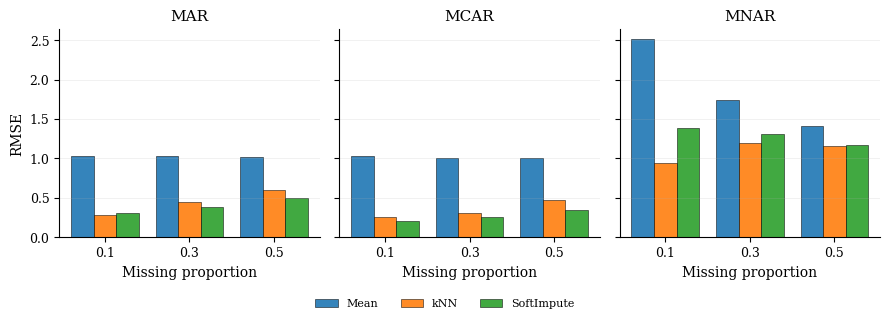

,Wasserstein,Mean shift,Var. retention,Corr. Frob.
Method,,,,
Mean,0.631,0.037,0.000,5.813
kNN,0.053,0.030,0.813,0.545
SoftImpute,0.078,0.006,0.767,0.570


In [20]:
from common.visualization import plot_metric_bars, err_table, stat_fidelity_table

# ---------------------------------------------------------------------------
# Usage — pass either a DataFrame or a path to a CSV. Both work everywhere.
# ---------------------------------------------------------------------------

results_df.to_csv(CSV_DIR / "scenario5_imputation_results.csv", index=False)   
data_source = results_df

plot_metric_bars(data_source, "rmse", "RMSE", filename= FIGURES_DIR / "scenario5_rmse.png")

for mech in scenario_filter:
    display(err_table(data_source, mech)) 

display(stat_fidelity_table(data_source, scenario="MCAR", proportion=0.3))

# Downstream task evaluation

In [ ]:
"""
Downstream beam-prediction evaluation for SQ3 (Scenario 5).

Pipeline per (mechanism, proportion, method, seed) cell:
  1. Split rows into train / test (a seeded random split is fine here).
  2. Ampute the training set's beam columns; test stays clean.
  3. Impute training beams.
  4. Labels: argmax over the 64 beams (clean for test, imputed-derived
     for train).
  5. Train the NN predictor on (GPS_train -> label_train).
  6. Evaluate Top-1 / Top-2 / Top-3 / Top-4 / Top-5 on clean test.
"""

import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------------------------
# Predictor: fully-connected NN (Morais & Alkhateeb, ICC 2023)
# ---------------------------------------------------------------------------

def predict_topk_mlp(gps_train, labels_train, gps_test,
                     n_classes=64, hidden=256, n_layers=3,
                     epochs=60, lr=1e-2, batch_size=32,
                     val_frac=0.25, seed=0, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(seed)
    np.random.seed(seed)

    y = labels_train.astype(int) - 1  # 1..64 -> 0..63

    # Internal train/val split (paper: 60/20/20 overall; here val out of train).
    n = len(gps_train)
    perm = np.random.default_rng(seed).permutation(n)
    n_val = max(1, int(round(val_frac * n)))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    Xtr = torch.tensor(gps_train[tr_i], dtype=torch.float32, device=device)
    ytr = torch.tensor(y[tr_i],          dtype=torch.long,    device=device)
    Xva = torch.tensor(gps_train[val_i], dtype=torch.float32, device=device)
    yva = torch.tensor(y[val_i],          dtype=torch.long,    device=device)
    Xte = torch.tensor(gps_test,          dtype=torch.float32, device=device)

    layers, in_dim = [], gps_train.shape[1]
    for _ in range(n_layers):
        layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        in_dim = hidden
    layers += [nn.Linear(in_dim, n_classes)]
    model = nn.Sequential(*layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.2)
    loss_fn = nn.CrossEntropyLoss()

    best_state, best_val_acc = None, -1.0
    idx = np.arange(len(tr_i))
    for epoch in range(epochs):
        model.train()
        np.random.shuffle(idx)
        for s in range(0, len(idx), batch_size):
            b = idx[s:s + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)  # best-val epoch, per the paper
    model.eval()
    with torch.no_grad():
        logits = model(Xte).cpu().numpy()

    ranked_idx = np.argsort(-logits, axis=1)
    return ranked_idx + 1  # back to 1..64


# ---------------------------------------------------------------------------
# Metric: Top-K accuracy from ranked candidates
# ---------------------------------------------------------------------------

def topk_accuracy(ranked_labels, true_labels, top_k=(1, 2, 3, 4, 5)):
    """ranked_labels: (n_test, n_classes), true_labels: (n_test,)."""
    out = {}
    for k in top_k:
        in_topk = np.any(ranked_labels[:, :k] == true_labels[:, None], axis=1)
        out[f"top{k}_acc"] = float(in_topk.mean())
    return out


# ---------------------------------------------------------------------------
# One downstream evaluation: (data_scaled, mask, imputer) -> metrics
# ---------------------------------------------------------------------------

def downstream_eval(data_scaled, beam_idx, gps_idx, mask, imputer, seed,
                    test_size=0.2):
    n_rows = data_scaled.shape[0]

    # Reproducible train/test split per seed.
    train_idx, test_idx = train_test_split(
        np.arange(n_rows), test_size=test_size, random_state=seed,
    )

    # --- Build the training matrix with masked beams; test stays clean. ---
    # The imputer is run ONLY on training rows. Otherwise test labels would
    # depend on imputation, defeating the point of held-out evaluation.
    data_train_masked = data_scaled[train_idx].copy()
    mask_train = mask[train_idx]
    data_train_masked[mask_train] = np.nan

    data_train_imputed = imputer.fit_transform(data_train_masked, seed=seed)

    # Defensive: fill any leftover NaNs with column means.
    if np.isnan(data_train_imputed).any():
        col_means = np.nanmean(data_train_masked, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_pos = np.isnan(data_train_imputed)
        data_train_imputed[nan_pos] = np.take(col_means, np.where(nan_pos)[1])

    # --- Derive labels: argmax across the 64 beam columns ---
    # Train labels come from imputed beams (the experimental variable).
    # Test labels come from clean beams (the ground truth).
    train_beams_imputed = data_train_imputed[:, beam_idx]
    test_beams_clean    = data_scaled[test_idx][:, beam_idx]

    labels_train = np.argmax(train_beams_imputed, axis=1) + 1   # 1..64
    labels_test  = np.argmax(test_beams_clean,    axis=1) + 1

    # --- Inputs: GPS, never imputed ---
    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]

    # --- Train + evaluate ---
    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 2, 3, 4, 5))

In [30]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from common.amputation import build_mask   

def downstream_eval_clean(data_scaled, beam_idx, gps_idx, seed, test_size=0.2):
    """Upper bound: no amputation, train on clean labels."""
    n_rows = data_scaled.shape[0]
    train_idx, test_idx = train_test_split(
        np.arange(n_rows), test_size=test_size, random_state=seed,
    )
    labels_train = np.argmax(data_scaled[train_idx][:, beam_idx], axis=1) + 1
    labels_test  = np.argmax(data_scaled[test_idx][:,  beam_idx], axis=1) + 1
    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]
    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 2, 3, 4, 5))

def run_downstream_experiments(clean_data, cfg, imputers,
                               gps_predictor_cols=("unit2_lat", "unit2_lon"),
                               scenario_filter=None, verbose=True):
    cfg.validate(clean_data)
    data_scaled = cfg.scale(clean_data)

    beam_idx       = cfg.target_idx         
    mar_driver_idx = cfg.mar_driver_idx
    gps_idx        = cfg.col_index(list(gps_predictor_cols))

    scenarios = cfg.scenarios
    if scenario_filter is not None:
        scenarios = [s for s in scenarios if s[0] in scenario_filter]

    records = []
    t_start = time.time()

    for seed in range(cfg.n_seeds):
        res = downstream_eval_clean(data_scaled, beam_idx, gps_idx, seed)
        for sc_name, _ in scenarios:
            for prop in cfg.proportions:
                records.append({
                    "scenario": sc_name, "proportion": prop,
                    "method": "Clean", "seed": seed, **res,
                })

    for scenario_name, mechanism in scenarios:
        for prop in cfg.proportions:
            for seed in range(cfg.n_seeds):
                rng = np.random.default_rng(seed)
                mask = build_mask(mechanism, data_scaled, prop,
                                  beam_idx, rng, driver_col_idx=mar_driver_idx)

                for imputer in imputers:
                    t0 = time.time()
                    res = downstream_eval(
                        data_scaled, beam_idx, gps_idx, mask, imputer, seed,
                    )
                    records.append({
                        "scenario": scenario_name, "proportion": prop,
                        "method": imputer.name, "seed": seed, **res,
                    })
                    if verbose:
                        print(f"  {scenario_name} p={prop} {imputer.name}: ",
                              f"{time.time() - t0:.1f}s")

    if verbose:
        print(f"\nTotal runtime: {time.time() - t_start:.1f}s")

    return pd.DataFrame(records)

In [28]:
downstream_df = run_downstream_experiments(clean_data, cfg, imputers=imputers, verbose=True)

downstream_df.to_csv(CSV_DIR / "scenario5_downstream_test.csv", index=False)

methods = ["Clean", "Mean", "kNN", "MICE", "HyperImpute",
           "SoftImpute", "GRAPE", "DiffPuter"]

  MCAR p=0.1 Mean: 3.8s
  MCAR p=0.1 kNN: 4.4s
  MCAR p=0.1 SoftImpute: 4.3s
  MCAR p=0.3 Mean: 4.0s
  MCAR p=0.3 kNN: 4.4s
  MCAR p=0.3 SoftImpute: 4.4s
  MCAR p=0.5 Mean: 4.0s
  MCAR p=0.5 kNN: 4.8s
  MCAR p=0.5 SoftImpute: 4.7s
  MAR p=0.1 Mean: 4.0s
  MAR p=0.1 kNN: 4.4s
  MAR p=0.1 SoftImpute: 4.2s
  MAR p=0.3 Mean: 3.9s
  MAR p=0.3 kNN: 4.6s
  MAR p=0.3 SoftImpute: 4.3s
  MAR p=0.5 Mean: 3.9s
  MAR p=0.5 kNN: 4.8s
  MAR p=0.5 SoftImpute: 4.7s
  MNAR p=0.1 Mean: 3.9s
  MNAR p=0.1 kNN: 4.3s
  MNAR p=0.1 SoftImpute: 4.5s
  MNAR p=0.3 Mean: 3.9s
  MNAR p=0.3 kNN: 4.8s
  MNAR p=0.3 SoftImpute: 4.6s
  MNAR p=0.5 Mean: 3.9s
  MNAR p=0.5 kNN: 4.9s
  MNAR p=0.5 SoftImpute: 4.7s

Total runtime: 121.3s


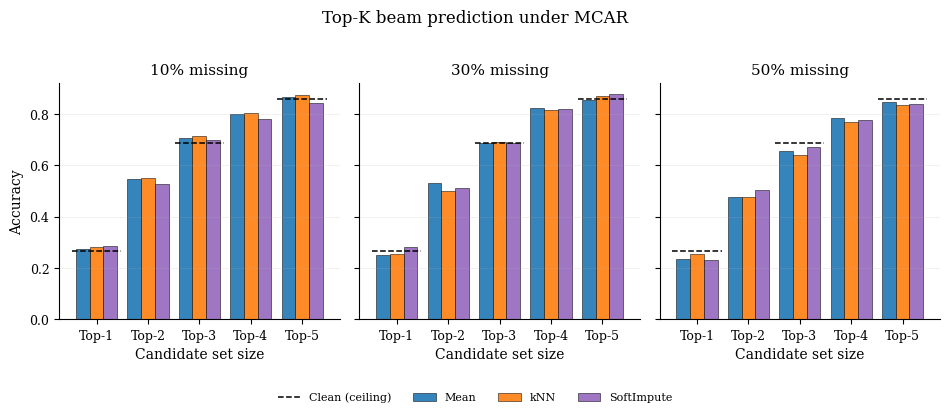

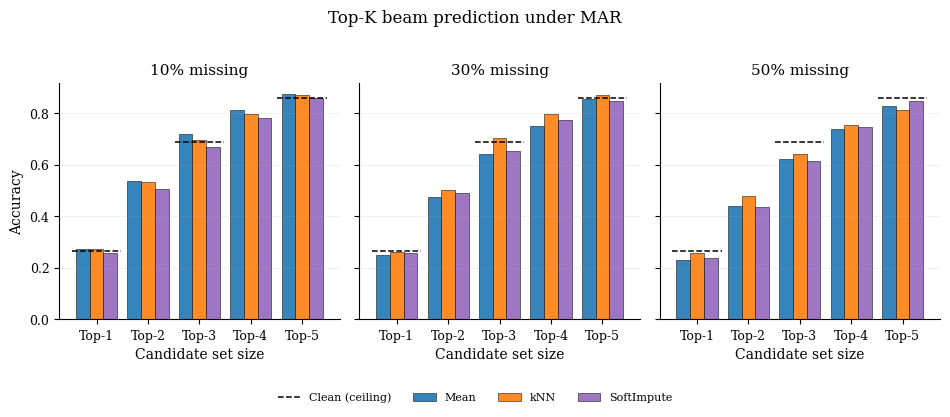

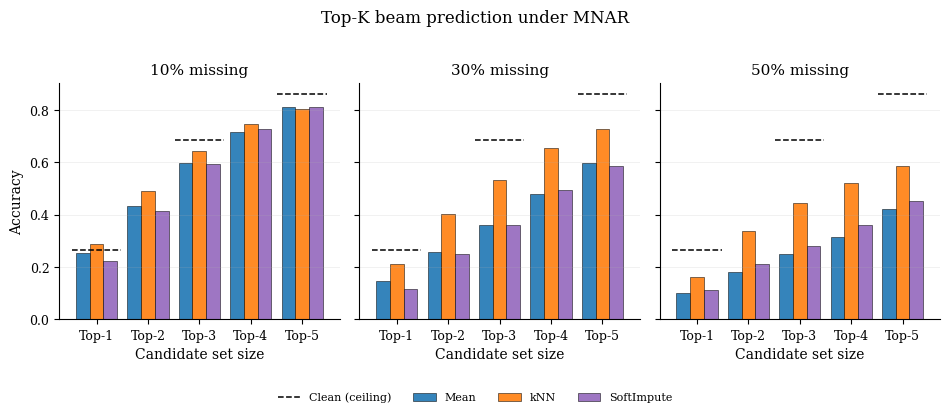

In [29]:
"""
Scenario-5 downstream Top-K plots.
"""

IMPUTER_METHODS = ["Mean", "kNN", "MICE", "HyperImpute",
                   "SoftImpute", "GRAPE", "DiffPuter"]


def _as_dataframe(data):
    if isinstance(data, pd.DataFrame):
        return data
    return pd.read_csv(data)


def _present_imputers(sub):
    present = set(sub["method"].unique())
    return [m for m in IMPUTER_METHODS if m in present]

def _draw_topk_panel(ax, sub, methods, show_ylabel, show_legend):
    ks = [1, 2, 3, 4, 5]
    metrics = [f"top{k}_acc" for k in ks]
    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(IMPUTER_METHODS)}
    bar_width = 0.8 / max(len(methods), 1)
    group_centers = np.arange(len(ks))

    for i, m in enumerate(methods):
        msub = sub[sub["method"] == m]
        means = [msub[met].mean() for met in metrics]
        stds  = [msub[met].std()  for met in metrics]
        offsets = group_centers - 0.4 + (i + 0.5) * bar_width
        ax.bar(offsets, means, width=bar_width, yerr=stds, label=m,
               color=method_color[m], edgecolor="black", linewidth=0.4,
               error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="black"),
               alpha=0.9)
        
    clean = sub[sub["method"] == "Clean"]
    if not clean.empty:
        tick_half = bar_width * len(methods) / 2 + bar_width * 0.3
        for j, met in enumerate(metrics):
            ax.hlines(clean[met].mean(),
                      group_centers[j] - tick_half, group_centers[j] + tick_half,
                      color="black", linestyle="--", linewidth=1.1,
                      label="Clean (ceiling)" if j == 0 else None, zorder=10)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([f"Top-{k}" for k in ks])
    ax.set_xlabel("Candidate set size")
    if show_ylabel:
        ax.set_ylabel("Accuracy")
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if show_legend:
        ax.legend(loc="lower right", ncol=2, fontsize=8, frameon=False)


def plot_topk_comparison_grid(data, scenario="MAR", proportions=None,
                              filename=None, methods=None):
    df = _as_dataframe(data)
    sc = df[df["scenario"] == scenario]
    proportions = proportions or sorted(sc["proportion"].unique())
    methods = methods or _present_imputers(sc)

    fig, axes = plt.subplots(1, len(proportions),
                             figsize=(3.2 * len(proportions), 3.6),
                             sharey=True)
    if len(proportions) == 1 and not hasattr(axes, "__iter__"):
        axes = [axes]

    for ax_i, (ax, p) in enumerate(zip(axes, proportions)):
        sub = sc[sc["proportion"] == p]
        _draw_topk_panel(ax, sub, methods,
                         show_ylabel=(ax_i == 0), show_legend=False)
        ax.set_title(f"{int(p*100)}% missing")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 5),
               bbox_to_anchor=(0.5, -0.10), frameon=False)
    fig.suptitle(f"Top-K beam prediction under {scenario}", y=1.02)
    fig.tight_layout()
    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------------
# Usage
# ---------------------------------------------------------------------------

for mech in ["MCAR", "MAR", "MNAR"]:
    plot_topk_comparison_grid(downstream_df, scenario=mech,
                            filename=FIGURES_DIR / f"sq3_topk_grid_{mech}.png")
